#Shifatual Alom
#201-67-060

# Reading data

In [1]:
import pandas as pd
df=pd.read_csv("marketing_data.csv")
df.head()

,Campaign_ID,Campaign_Type,Ad_Spend,Revenue,CTR_Percentage
0,CMP_000,Email,538.26,156.75,2.35
1,CMP_001,Social Media,14334.36,62909.77,4.08
2,CMP_002,Email,1752.60,1222.14,3.46
3,CMP_003,Email,1848.44,0.00,4.62
4,CMP_004,Social Media,11839.64,53060.46,6.10


#Section 1- Distribution and Outlier Analysis

#Question 1

/tmp/ipykernel_3780/1238583458.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Campaign_Type", y="Revenue", data=df, palette="Set2", linewidth=1.5)


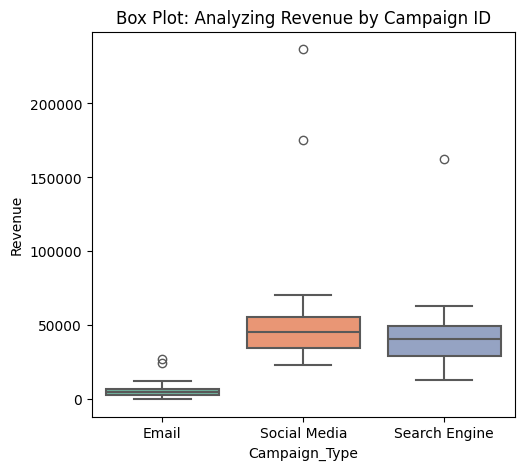

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x="Campaign_Type", y="Revenue", data=df, palette="Set2", linewidth=1.5)
plt.xlabel("Campaign_Type")
plt.ylabel("Revenue")
plt.title("Box Plot: Analyzing Revenue by Campaign ID")


plt.show()

Outliers above the upper whisker represent campaigns of that particular type that generated significantly higher revenue than the majority of other campaigns within the same type.

Outliers below the lower whisker (if any are present, which is less common for revenue unless there are negative or extremely low values) would indicate campaigns with unusually low revenue compared to their respective campaign type.

Essentially, these outliers highlight individual campaigns that deviate notably from the typical revenue performance of their group

# Question 2

/tmp/ipykernel_3780/3762260681.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Campaign_Type", y="Revenue", data=df, palette="Pastel1")


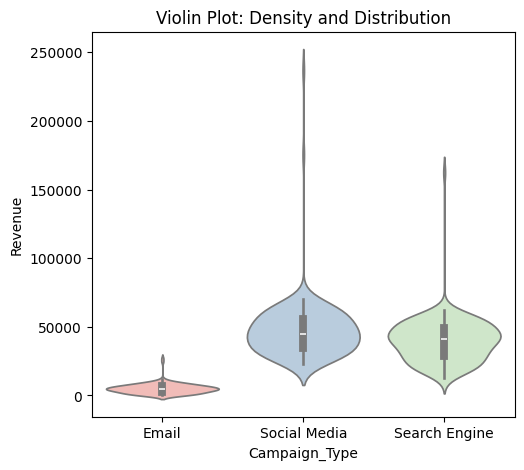

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
# Violin Plot
plt.subplot(1, 2, 2)
sns.violinplot(x="Campaign_Type", y="Revenue", data=df, palette="Pastel1")
plt.title("Violin Plot: Density and Distribution")

plt.show()

From the Violin Plot, we can see that Campaign type "Email " has the highest density of low revenue sales. Because the other two campaign types demonstrate high revenue sales than "Email".

# Question 3

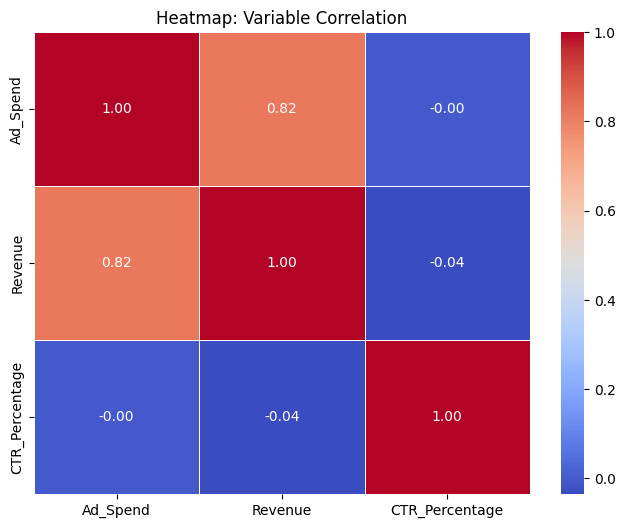

In [14]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap: Variable Correlation")
plt.show()

Correlation between 'CTR_Percentage' and 'Ad_Spend': The correlation coefficient between CTR_Percentage and Ad_Spend is -.00. This value is very close to zero, indicating that there is virtually no linear correlation between Click-Through Rate and Ad Spend in this dataset. This means that as Ad Spend increases or decreases, CTR does not show a consistent linear pattern of change.

The potential problems are unstable coefficient estimates,difficulty in interpretation.

#Section 2


#Question 1

In [21]:
import pandas as pd
import statsmodels.api as sm

import pandas as pd
df=pd.read_csv("marketing_data.csv")
df_social_media=df[df['Campaign_Type']== 'Social Media']

# 2. Define X and Y
X = df_social_media['Ad_Spend']
Y = df_social_media['Revenue']

# 3. Add a constant (intercept) - statsmodels doesn't add it by default
X = sm.add_constant(X)

# 4. Fit the OLS (Ordinary Least Squares) model
model = sm.OLS(Y, X).fit()

# 5. Print the results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     112.0
Date:                Thu, 07 May 2026   Prob (F-statistic):           2.54e-20
Time:                        06:20:59   Log-Likelihood:                -1872.2
No. Observations:                 168   AIC:                             3748.
Df Residuals:                     166   BIC:                             3755.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1372.8872   4775.580     -0.287      0.7

In [22]:
import pandas as pd
import statsmodels.api as sm

import pandas as pd
df=pd.read_csv("marketing_data.csv")
df_social_media=df[df['Campaign_Type']== 'Search Engine']

# 2. Define X and Y
X = df_social_media['Ad_Spend']
Y = df_social_media['Revenue']

# 3. Add a constant (intercept) - statsmodels doesn't add it by default
X = sm.add_constant(X)

# 4. Fit the OLS (Ordinary Least Squares) model
model = sm.OLS(Y, X).fit()

# 5. Print the results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.672
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     337.7
Date:                Thu, 07 May 2026   Prob (F-statistic):           9.24e-42
Time:                        06:21:34   Log-Likelihood:                -1757.8
No. Observations:                 167   AIC:                             3520.
Df Residuals:                     165   BIC:                             3526.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        609.7230   2244.636      0.272      0.7

#So the second model consisting Search Engine gives more ROI.

#Question 2

#Calculation



Predicted Revenue Calculation for Social Media Ads:

From the OLS model summary for 'Social Media'

Intercept (const) = -1372.8872
Coefficient for Ad_Spend = 4.9713

\begin{align}
$Revenue = -1372.8872 + (15000 * 4.9713)
\end{align}
\begin{align}
Revenue = 73,196.61
\end{align}


Therefore, the predicted revenue for a $15,000 Ad Spend on Social Media is approximately 73196.61
